In [1]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# Notebook 2: Data Preprocessing & Augmentation
# ============================================================
# This notebook covers:
# - Resize all images to 224x224
# - Normalize pixel values to 0-1 range
# - Apply data augmentation to training set
# - Verify augmented image samples
# - Prepare ImageDataGenerators for model training
# ============================================================

In [1]:
pip install "numpy<2" --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, ImageEnhance
import random
import warnings
warnings.filterwarnings('ignore')

print(" Libraries imported successfully")
 

 Libraries imported successfully


# Paths & Parameters

In [8]:
BASE_DIR  = "../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASSES     = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

print(f" Target image size : {IMG_SIZE}")
print(f" Batch size        : {BATCH_SIZE}")
print(f" Classes           : {CLASSES}")

 Target image size : (224, 224)
 Batch size        : 32
 Classes           : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


#  Demonstrate Resize + Normalize

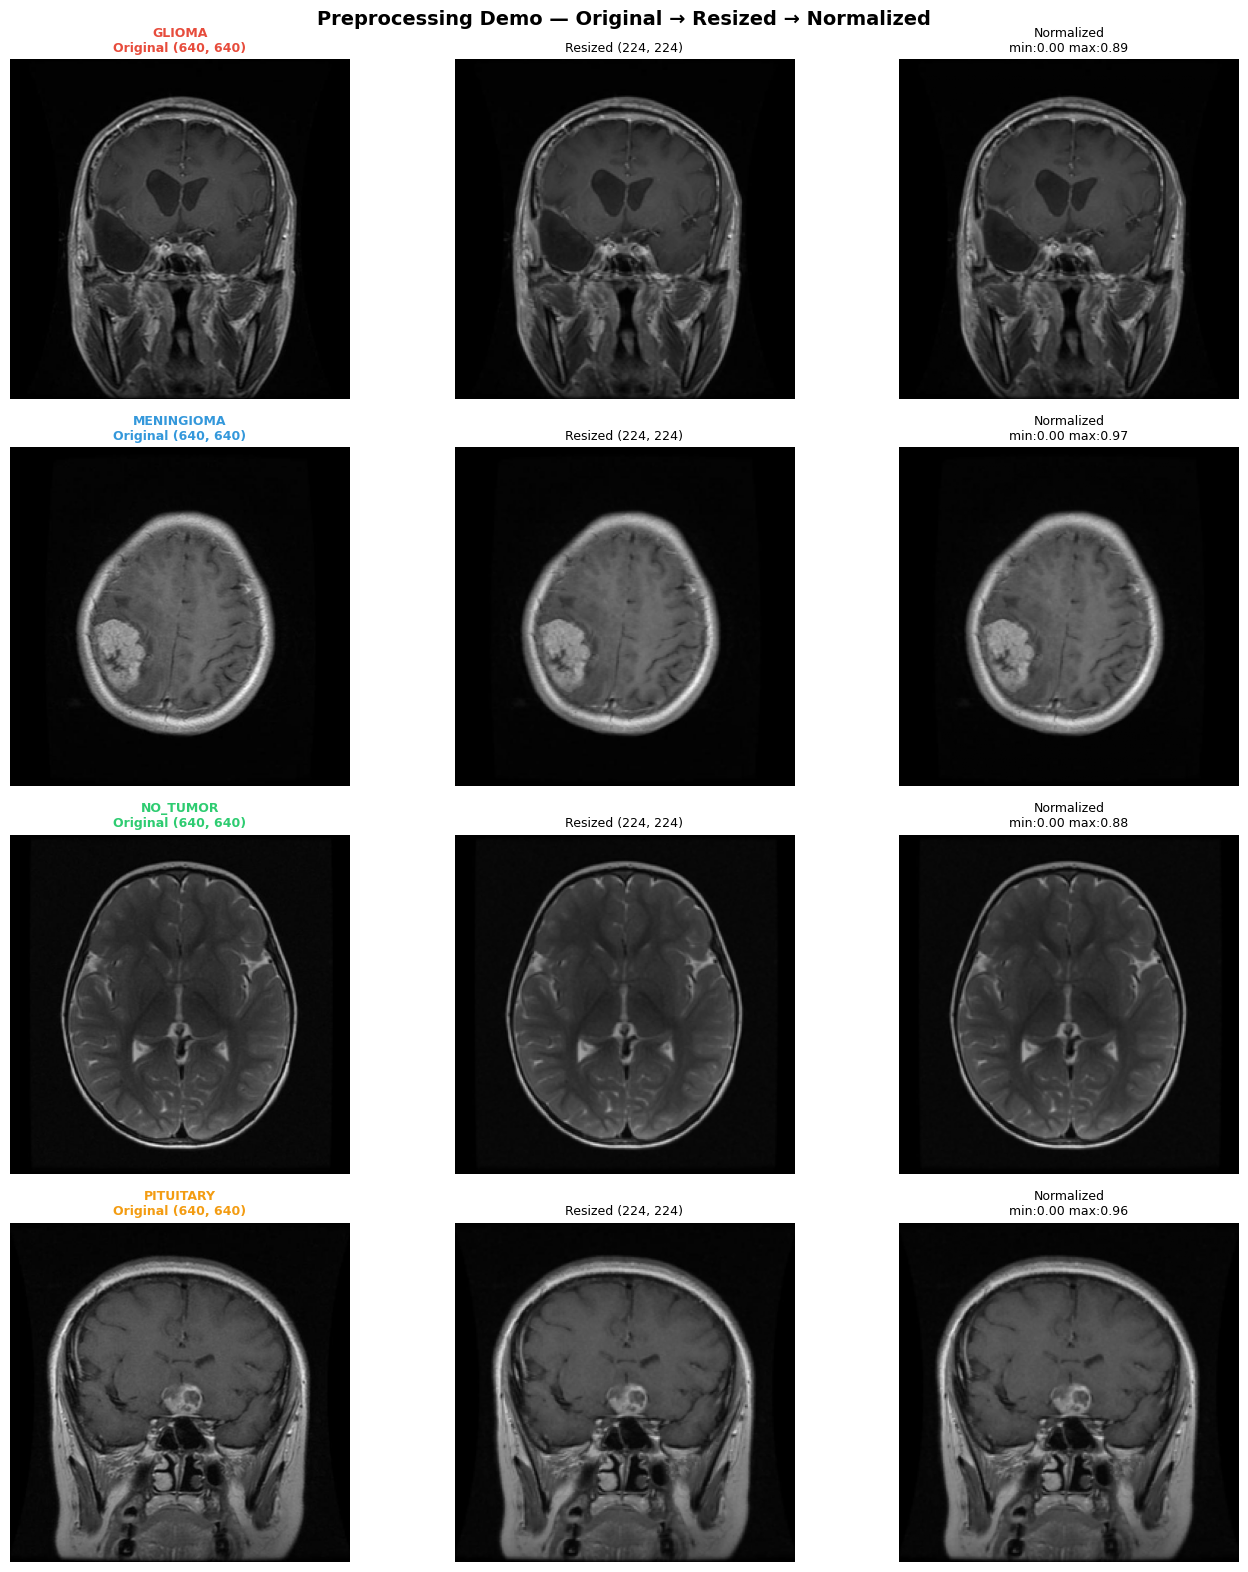

 Preprocessing demo saved


In [11]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(4, 3, figsize=(14, 16))
fig.suptitle('Preprocessing Demo — Original → Resized → Normalized',
             fontsize=14, fontweight='bold')

for row, (cls, color) in enumerate(zip(CLASSES, colors)):
    cls_path  = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img_path  = os.path.join(cls_path, img_files[0])

    # Original
    orig = Image.open(img_path).convert('RGB')
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'{cls.upper()}\nOriginal {orig.size}',
                            fontsize=9, color=color, fontweight='bold')
    axes[row, 0].axis('off')

    # Resized
    resized = orig.resize(IMG_SIZE)
    axes[row, 1].imshow(resized)
    axes[row, 1].set_title(f'Resized {IMG_SIZE}', fontsize=9)
    axes[row, 1].axis('off')

    # Normalized (pixel values 0-1)
    norm_array = np.array(resized) / 255.0
    axes[row, 2].imshow(norm_array)
    axes[row, 2].set_title(
        f'Normalized\nmin:{norm_array.min():.2f} max:{norm_array.max():.2f}',
        fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('../data/preprocessing_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Preprocessing demo saved")

#  Demonstrate Augmentation (PIL only)

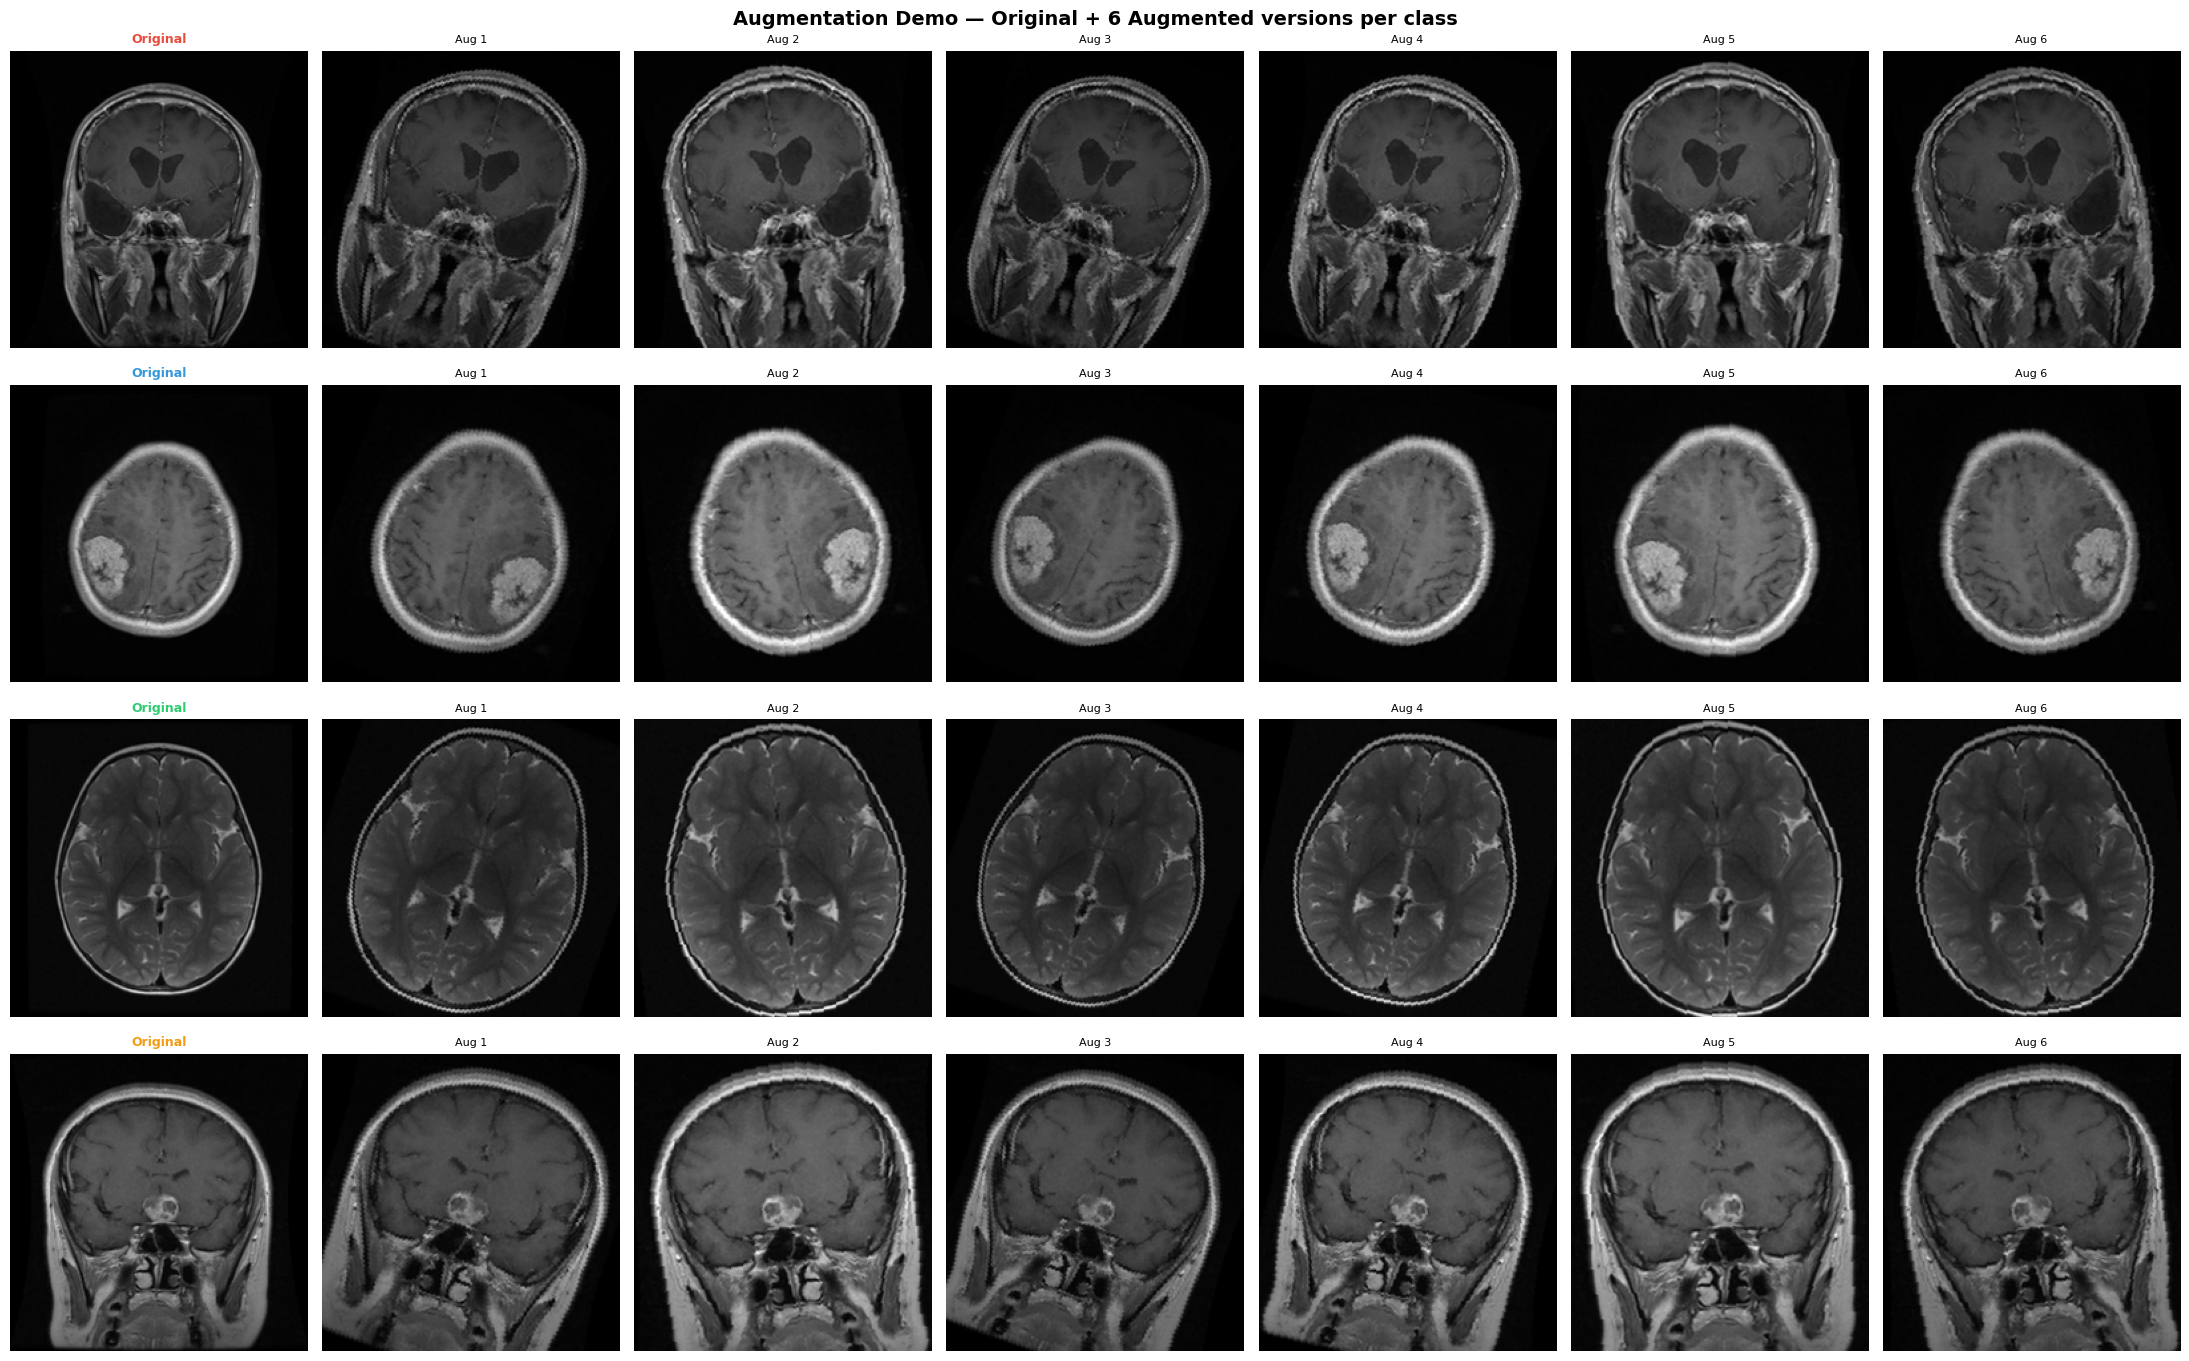

 Augmentation demo saved


In [14]:
def augment_image_pil(img):
    """Apply random augmentations using PIL only"""
    import random

    # Random horizontal flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random rotation
    angle = random.uniform(-20, 20)
    img = img.rotate(angle, fillcolor=(0, 0, 0))

    # Random brightness
    factor = random.uniform(0.8, 1.2)
    img = ImageEnhance.Brightness(img).enhance(factor)

    # Random zoom (crop then resize)
    zoom = random.uniform(0.85, 1.0)
    w, h = img.size
    new_w, new_h = int(w * zoom), int(h * zoom)
    left   = (w - new_w) // 2
    top    = (h - new_h) // 2
    img    = img.crop((left, top, left + new_w, top + new_h))
    img    = img.resize((w, h), Image.LANCZOS)

    return img

fig, axes = plt.subplots(4, 7, figsize=(22, 14))
fig.suptitle('Augmentation Demo — Original + 6 Augmented versions per class',
             fontsize=14, fontweight='bold')

for row, (cls, color) in enumerate(zip(CLASSES, colors)):
    cls_path  = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img_path  = os.path.join(cls_path, img_files[0])
    orig      = Image.open(img_path).convert('RGB').resize(IMG_SIZE)

    # Original
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title('Original', fontsize=9, fontweight='bold', color=color)
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(cls.upper(), fontsize=9)

    # 6 augmented versions
    random.seed(42)
    for col in range(1, 7):
        aug = augment_image_pil(orig.copy())
        axes[row, col].imshow(aug)
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../data/augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Augmentation demo saved")

# Summary

In [17]:
print("=" * 55)
print("   PREPROCESSING & AUGMENTATION SUMMARY")
print("=" * 55)
print(f"""
  PREPROCESSING:
    Resize    : 640x640 → 224x224
    Normalize : 0-255   → 0.0-1.0
    Mode      : RGB (3 channels)

  AUGMENTATION (applied in Colab training):
    Rotation          : ±20°
    Width/Height shift: ±10%
    Horizontal flip   : Yes
    Zoom              : ±15%
    Brightness        : 0.8x – 1.2x
    Fill mode         : nearest

  TRAINING STRATEGY:
     Notebooks 1 & 2  → Local Jupyter (no TF needed)
     Notebooks 3,4,5  → Google Colab (free GPU)
     Notebook 6 + app → Local Jupyter + Streamlit

  Next Step → Notebook 3 on Google Colab
""")
print("=" * 55)

   PREPROCESSING & AUGMENTATION SUMMARY

  PREPROCESSING:
    Resize    : 640x640 → 224x224
    Normalize : 0-255   → 0.0-1.0
    Mode      : RGB (3 channels)

  AUGMENTATION (applied in Colab training):
    Rotation          : ±20°
    Width/Height shift: ±10%
    Horizontal flip   : Yes
    Zoom              : ±15%
    Brightness        : 0.8x – 1.2x
    Fill mode         : nearest

  TRAINING STRATEGY:
     Notebooks 1 & 2  → Local Jupyter (no TF needed)
     Notebooks 3,4,5  → Google Colab (free GPU)
     Notebook 6 + app → Local Jupyter + Streamlit

  Next Step → Notebook 3 on Google Colab

